In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../week2/shoppers_clean.csv')
print(df.shape)
df.head()


(12330, 28)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.293024
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.325076
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-0.998552


In [2]:
cluster_features = [
    'Administrative_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]

X_cluster = df[cluster_features].copy()

print(f"Izmantojam {len(cluster_features)} iezīmes:")
print(cluster_features)

X_cluster.head()

Izmantojam 5 iezīmes:
['Administrative_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


,Administrative_Duration,ProductRelated_Duration,BounceRates,ExitRates,PageValues
0,-0.457191,-0.624348,3.667189,3.229316,-0.317178
1,-0.457191,-0.590903,-0.457683,1.171473,-0.317178
2,-0.457191,-0.624348,3.667189,3.229316,-0.317178
3,-0.457191,-0.622954,0.573535,1.994610,-0.317178
4,-0.457191,-0.296430,-0.045196,0.142551,-0.317178


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print("Pēc normalizācijas:")
X_scaled_df.describe().round(2)


Pēc normalizācijas:


,Administrative_Duration,ProductRelated_Duration,BounceRates,ExitRates,PageValues
count,12330.00,12330.00,12330.00,12330.00,12330.00
mean,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.46,-0.62,-0.46,-0.89,-0.32
25%,-0.46,-0.53,-0.46,-0.59,-0.32
50%,-0.41,-0.31,-0.39,-0.37,-0.32
75%,0.07,0.14,-0.11,0.14,-0.32
max,18.77,32.81,3.67,3.23,19.17


### Datu normalizācijas nozīme

K-Means algoritms balstās uz attālumu starp punktiem.
Ja iezīmēm ir dažādi mērogi, modelis pieņemtu lēmumus, balstoties tikai uz lielākajām vērtībām.
Normalizācija nodrošina, ka visas iezīmes ir vienā skalā un vienlīdz ietekmē rezultātu.
Bez normalizācijas klasterizācija būtu neprecīza.

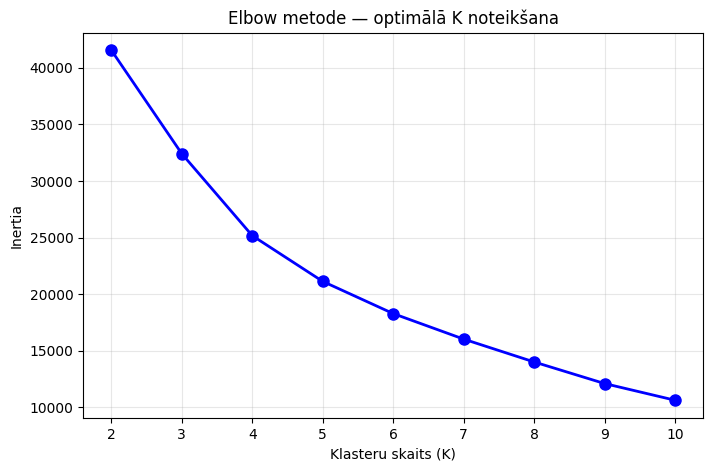

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.show()

### Optimālā klasteru skaita izvēle

Tika analizēts klasteru skaits diapazonā no 2 līdz 10, izmantojot Elbow metodi.

Grafikā redzams, ka inertia strauji samazinās līdz K = 4, pēc kā samazinājums kļūst ievērojami lēnāks.

Tas norāda, ka pie K = 4 tiek sasniegts optimāls līdzsvars starp modeļa vienkāršību un precizitāti.

Tāpēc tika izvēlēts K = 4.

Jāatzīmē, ka šī izvēle nav absolūta — tā balstās uz vizuālu interpretāciju.


In [5]:
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0     942
1     931
2    9798
3     659
Name: count, dtype: int64


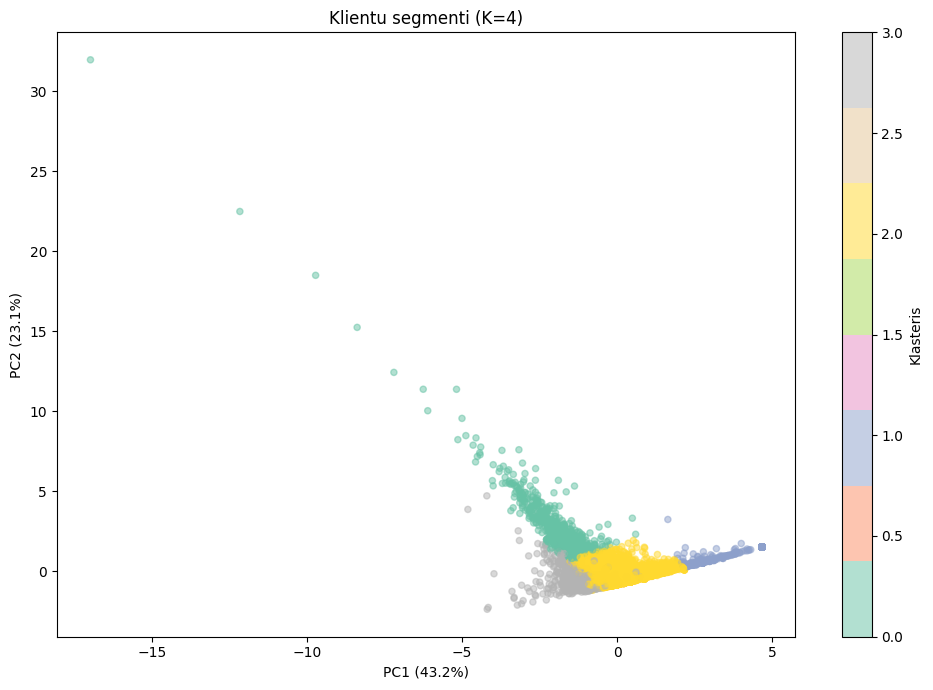

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster'],
    cmap='Set2',
    alpha=0.5,
    s=20
)

plt.colorbar(scatter, label='Klasteris')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.title(f'Klientu segmenti (K={K})')

plt.tight_layout()
plt.show()

### Klasteru vizualizācija (PCA)

Izmantojot PCA, dati tika samazināti līdz 2 dimensijām, lai vizualizētu klientu segmentus.

Grafikā redzams, ka daļa klasteru pārklājas, kas norāda, ka klientu uzvedība nav pilnībā atdalāma.

Tomēr ir redzamas tendences un virzieni, kuros konkrēti segmenti atšķiras.

Tas ir tipiski reāliem datiem, kur segmentācija nav ideāli skaidra, bet joprojām sniedz vērtīgu ieskatu.

In [7]:
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)

print("Klasteru profili:")
print(cluster_profiles)

Klasteru profili:
         Administrative_Duration  ProductRelated_Duration  BounceRates  \
Cluster                                                                  
0                           2.14                     2.02        -0.33   
1                          -0.45                    -0.60         3.24   
2                          -0.17                    -0.14        -0.25   
3                           0.05                     0.02        -0.40   

         ExitRates  PageValues  
Cluster                         
0            -0.48        0.00  
1             2.96       -0.32  
2            -0.20       -0.19  
3            -0.59        3.33  


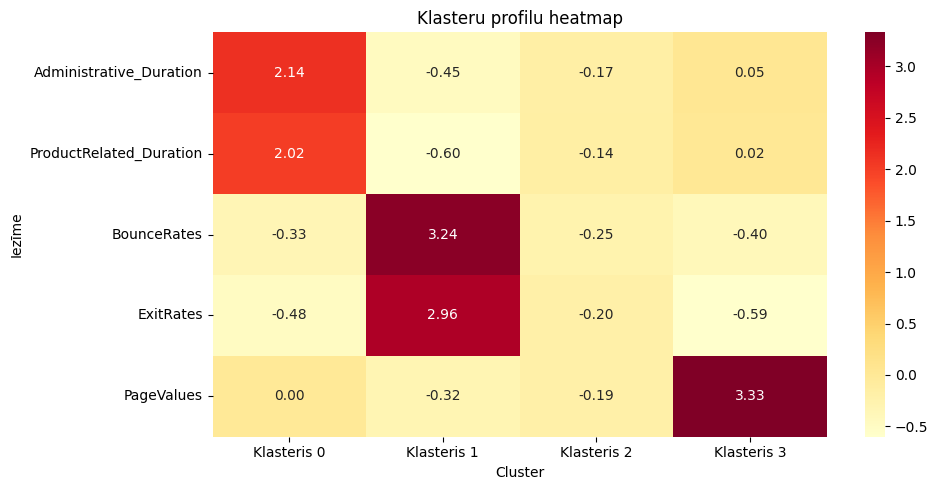

In [8]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    cluster_profiles.T,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=[f'Klasteris {i}' for i in range(K)]
)

plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')

plt.tight_layout()
plt.show()

### Klientu segmentu interpretācija

Balstoties uz klasteru analīzi, tika identificēti četri galvenie klientu segmenti:

**Klasteris 0 – “Iesaistītie, bet nepērk”**
Šie lietotāji pavada daudz laika lapā un aktīvi pārlūko saturu, taču neveic pirkumu.
👉 Rekomendācija: izmantot retargeting reklāmas vai īpašus piedāvājumus, lai pārvērstu viņus pircējos.

---

**Klasteris 1 – “Ātrie aizgājēji”**
Šiem lietotājiem ir ļoti augsts bounce un exit rate, kas nozīmē, ka viņi ātri pamet lapu.
👉 Rekomendācija: uzlabot landing page, piedāvājumu vai UX, lai noturētu lietotāju.

---

**Klasteris 2 – “Vidējie lietotāji”**
Lielākā klientu grupa ar vidējiem rādītājiem visās iezīmēs.
👉 Rekomendācija: optimizēt vispārējo lietotāja pieredzi un pakāpeniski virzīt uz konversiju.

---

**Klasteris 3 – “Augstas vērtības pircēji”**
Šie lietotāji ir ar augstu PageValues un zemu bounce/exit rate, kas liecina par lielu pirkšanas varbūtību.
👉 Rekomendācija: piedāvāt VIP programmas, personalizētus piedāvājumus un lojalitātes bonusus.

---

Šāda segmentācija ļauj uzņēmumam pielāgot mārketinga stratēģiju katrai klientu grupai un palielināt konversijas līmeni.

Cluster
0    0.288
1    0.005
2    0.114
3    0.786
Name: Revenue, dtype: float64


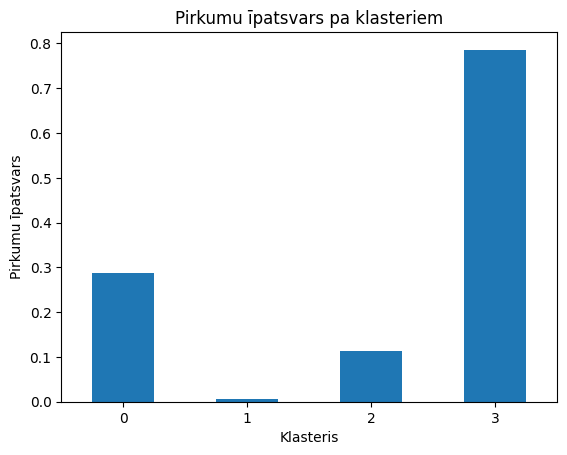

In [9]:
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)

print(purchase_by_cluster)

purchase_by_cluster.plot(kind='bar')
plt.title('Pirkumu īpatsvars pa klasteriem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.show()

### Klientu segmentācija un pirkumu uzvedība

Analizējot pirkumu īpatsvaru pa klasteriem, redzamas būtiskas atšķirības starp klientu grupām.

**Klasteris 3 – “Augstas vērtības pircēji”**
Šim segmentam ir ļoti augsts pirkumu īpatsvars (~78.6%).
-Šie ir galvenie uzņēmuma klienti.
-Rekomendācija: fokusēties uz lojalitātes programmām, personalizētiem piedāvājumiem un upsell iespējām.

---

**Klasteris 1 – “Zaudētā trafika”**
Šim segmentam ir gandrīz nulles konversija (~0.5%).
- Lietotāji ienāk, bet nepērk.
- Rekomendācija: uzlabot pirmo iespaidu (landing page), piedāvājumu vai reklāmu kvalitāti.

---

**Klasteris 0 – “Potenciālie pircēji”**
Vidējs pirkumu līmenis (~28.8%), kas norāda uz potenciālu.
- Rekomendācija: izmantot retargeting un motivējošus piedāvājumus, lai palielinātu konversiju.

---

**Klasteris 2 – “Zema iesaiste”**
Salīdzinoši zems pirkumu īpatsvars (~11.4%).
- Rekomendācija: uzlabot iesaisti un lietotāja ceļu (UX, saturs, piedāvājumi).

---

Secinājums:
Segmentācija skaidri parāda, ka dažādas klientu grupas uzvedas ļoti atšķirīgi, un vienota mārketinga pieeja nav efektīva.

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)

print(X.shape)

(12330, 27)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

rf.fit(X_train, y_train)

single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Single split F1: {single_f1:.3f}")


Single split F1: 0.635


In [12]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("CV F1 scores:", cv_scores.round(3))
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Std: {cv_scores.std():.3f}")

CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629
Std: 0.043


### Viena split vs Cross-validation

Viena train/test split rezultāts (F1 = 0.635) ir balstīts tikai uz vienu datu sadalījumu.

Cross-validation izmanto vairākus sadalījumus, kas dod stabilāku un uzticamāku rezultātu.

Vidējais F1 score labāk atspoguļo modeļa reālo veiktspēju.

Standarta novirze parāda, cik stabils modelis ir — jo mazāka, jo labāk.

In [13]:
from sklearn.preprocessing import StandardScaler

# ❌ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled_leak = scaler.fit_transform(X)  # FIT uz visiem datiem!

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled_leak, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_leak = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

rf_leak.fit(X_train_l, y_train_l)

f1_leak = f1_score(y_test_l, rf_leak.predict(X_test_l))

print(f"F1 ar data leakage: {f1_leak:.3f}")

F1 ar data leakage: 0.635


In [14]:
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

cv_scores_pipe = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(f"Pipeline F1: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

Pipeline F1: 0.629 ± 0.045


In [15]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage', 'Pipeline'],
    'F1 Score': [f1_leak, cv_scores_pipe.mean()],
    'Ticamība': ['❌ Neuzticams', '✅ Uzticams']
})

print(comparison)


         Metode  F1 Score      Ticamība
0  Data leakage  0.635258  ❌ Neuzticams
1      Pipeline  0.628553    ✅ Uzticams


### Data leakage un Pipeline nozīme

Data leakage notiek, kad modelis netīši izmanto informāciju no test datiem treniņa laikā.

Šajā gadījumā tas notika, jo StandardScaler tika pielāgots visiem datiem pirms datu sadalīšanas.

Tas rada mākslīgi augstāku F1 score, kas neatspoguļo modeļa reālo veiktspēju.

Pipeline novērš šo problēmu, nodrošinot, ka visi preprocessing soļi tiek veikti tikai uz treniņa datiem katrā cross-validation iterācijā.

Salīdzinot rezultātus, redzams, ka Pipeline dod nedaudz zemāku, bet daudz uzticamāku rezultātu.

Tas ir kritiski svarīgi, ja modeli plānots izmantot reālā biznesa vidē.

In [16]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print("Labākie parametri:", grid.best_params_)
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Test F1: {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1: 0.653
Test F1: 0.629


### GridSearchCV rezultātu interpretācija

Izmantojot GridSearchCV, tika atrasti optimālie RandomForest parametri.

Labākie parametri:
- max_depth = 20
- n_estimators = 100

Labākais cross-validation F1 score bija 0.653, kas ir uzlabojums salīdzinājumā ar sākotnējo modeli.

Testa F1 score (0.629) ir tuvs cross-validation rezultātam, kas norāda, ka modelis nav pārāk pielāgots (overfitted).

Tas nozīmē, ka izvēlētie parametri uzlabo modeļa veiktspēju un saglabā stabilitāti.

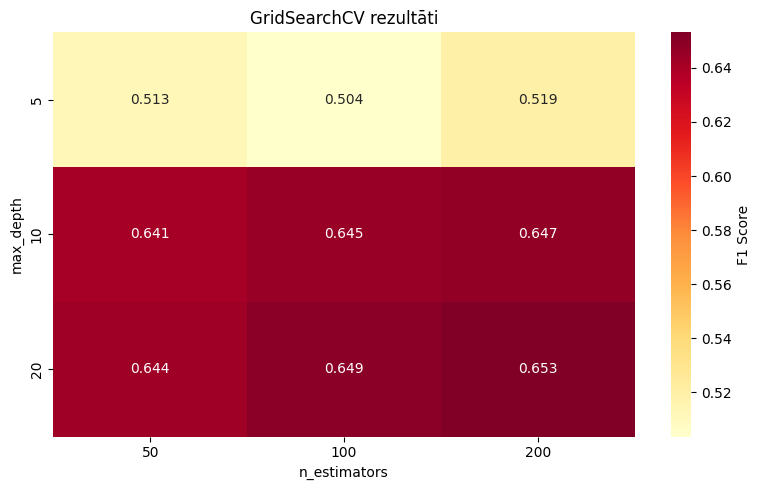

In [17]:
results_df = pd.DataFrame(grid.cv_results_)

pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)

plt.title('GridSearchCV rezultāti')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')

plt.tight_layout()
plt.show()

### GridSearchCV heatmap interpretācija

Heatmap vizualizācija parāda, kā dažādas parametru kombinācijas ietekmē modeļa F1 score.

Redzams, ka zemākais sniegums ir pie max_depth = 5, kas norāda, ka modelis ir pārāk vienkāršs.

Palielinot max_depth uz 10 un 20, F1 score būtiski uzlabojas, kas nozīmē, ka datiem ir sarežģītāka struktūra.

Lielākais F1 score (~0.653) tiek sasniegts pie max_depth = 20 un n_estimators = 200.

Tāpat redzams, ka palielinot n_estimators virs 100, uzlabojums kļūst minimāls, kas norāda uz diminishing returns efektu.

Tas palīdz izvēlēties optimālu kompromisu starp veiktspēju un aprēķinu izmaksām.

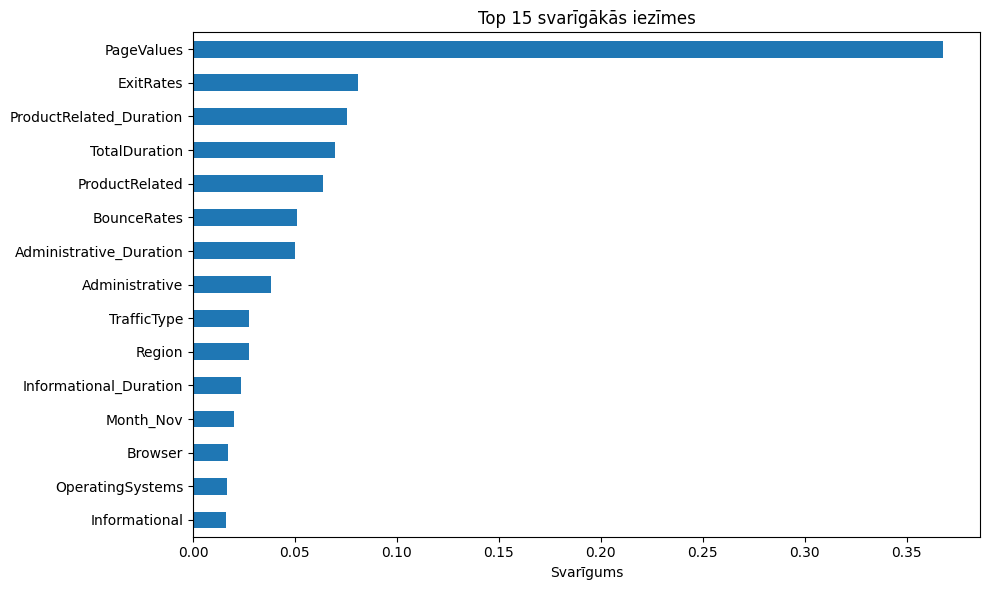

Top 10 features:
PageValues                 0.367569
ExitRates                  0.081168
ProductRelated_Duration    0.075586
TotalDuration              0.069522
ProductRelated             0.063952
BounceRates                0.050973
Administrative_Duration    0.049905
Administrative             0.038452
TrafficType                0.027520
Region                     0.027481
dtype: float64


In [18]:
best_model = grid.best_estimator_

rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

feature_importance.tail(15).plot(kind='barh')

plt.title('Top 15 svarīgākās iezīmes')
plt.xlabel('Svarīgums')

plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feature_importance.sort_values(ascending=False).head(10))

### Feature importance interpretācija

Balstoties uz RandomForest modeli, svarīgākās iezīmes pirkuma prognozēšanai ir:

1. PageValues  
2. ExitRates  
3. ProductRelated_Duration  

**PageValues** ir visnozīmīgākā iezīme, kas norāda uz lietotāja potenciālo vērtību un tiešu saistību ar pirkuma iespējamību.

**ExitRates** parāda, cik bieži lietotāji pamet lapu, kas negatīvi ietekmē konversiju.

**ProductRelated_Duration** un citi laika rādītāji liecina, ka ilgāka iesaiste korelē ar lielāku pirkuma iespēju.

Interesanti, ka demogrāfiskie un tehniskie rādītāji (piemēram, reģions, pārlūks) ir mazāk nozīmīgi.

- Biznesa pielietojums:
Uzņēmumam vajadzētu fokusēties uz lietotāja uzvedības uzlabošanu (UX, saturs, piedāvājumi), nevis tikai uz trafika piesaisti.

In [19]:
from xgboost import XGBClassifier

# RandomForest (ar labākajiem parametriem)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

print(f"RandomForest: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

c:\Users\edgar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\edgar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\edgar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\edgar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:56] WARNING: C:\actio

RandomForest: 0.635 ± 0.043
XGBoost:      0.614 ± 0.056


c:\Users\edgar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [20]:
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [
        f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
        f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"
    ]
})

print(comparison_table.to_string(index=False))

     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.634523 0.042623 0.572-0.689
     XGBoost        0.613835 0.056357 0.538-0.697


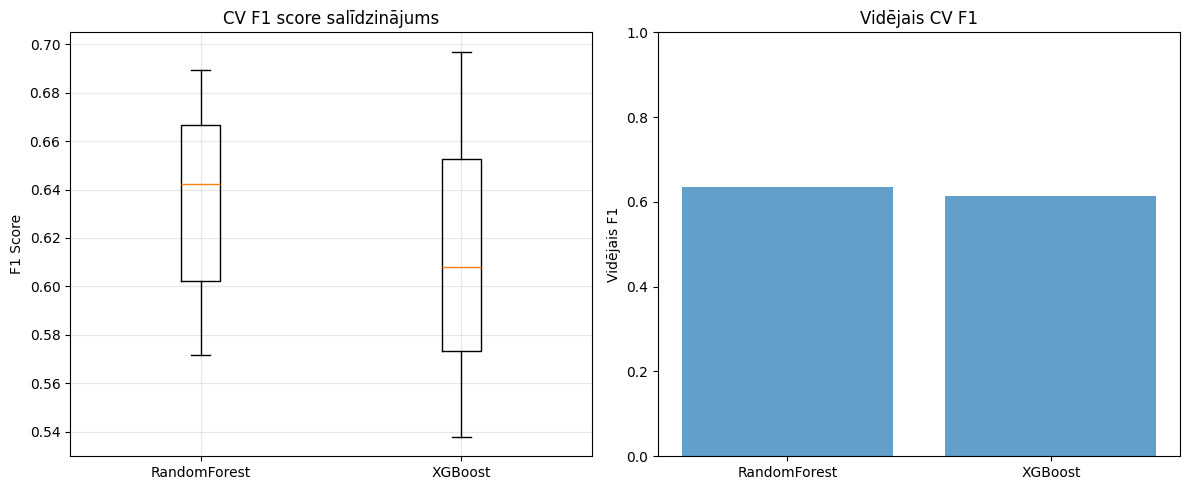

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, tick_labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 score salīdzinājums')
axes[0].grid(True, alpha=0.3)

# Bar plot
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], alpha=0.7)
axes[1].set_ylabel('Vidējais F1')
axes[1].set_title('Vidējais CV F1')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

### RandomForest un XGBoost salīdzinājums

Abi modeļi tika salīdzināti, izmantojot 5-fold cross-validation.

Rezultāti parādīja, ka RandomForest sasniedza augstāku vidējo F1 score nekā XGBoost, kā arī mazāku standarta novirzi.

Tas nozīmē, ka RandomForest šajā datu kopā ir gan precīzāks, gan stabilāks.

Tāpēc gala projektam es izvēlētos RandomForest modeli, jo tas dod labāku veiktspēju un uzticamāku rezultātu.

# Gala secinājumi

Šajā darbā tika veikta klientu segmentācija ar K-Means un modeļu validācija, izmantojot production-ready pieeju.

Galvenie secinājumi:
- ar Elbow metodi tika izvēlēti 4 klientu segmenti
- segmenti būtiski atšķiras pēc uzvedības un pirkumu īpatsvara
- īpaši izcēlās viens augstas vērtības pircēju segments un viens ļoti zemas konversijas segments
- cross-validation parādīja uzticamāku modeļa kvalitāti nekā viena train/test split pieeja
- Pipeline palīdz novērst data leakage un nodrošina korektu validāciju
- GridSearchCV uzlaboja RandomForest modeļa parametrus
- feature importance parādīja, ka svarīgākie faktori ir PageValues, ExitRates un ProductRelated_Duration
- modeļu salīdzinājumā RandomForest pārspēja XGBoost

Kopumā šī analīze parāda, ka klientu segmentācija un korekta modeļu validācija var sniegt praktisku biznesa vērtību un palīdzēt uzņēmumam pieņemt precīzākus lēmumus.